## Imports

In [1]:
from copy import deepcopy
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import transforms
import wandb

PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT))

from src.constants import EMOTION_LABELS, NUM_CLASSES, IMAGE_SIZE
from src.dataset import FER2013Dataset
from src.train_utils import (
    set_seed,
    get_device,
    count_parameters,
    train_one_epoch,
    evaluate,
)

## Configuration

In [2]:
CSV_PATH = PROJECT_ROOT / "data/raw/fer2013/fer2013.csv"

WANDB_ENTITY = "lkhiz23-free-university-of-tbilisi-"
WANDB_PROJECT = "facial-expression-recognition"

ENABLE_WANDB = True

IMAGES_DIR = PROJECT_ROOT / "images"
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINTS_DIR = PROJECT_ROOT / "checkpoints"
CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)

device = get_device()

print("Device:", device)

if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 3050 4GB Laptop GPU


## Data Loading

In [3]:
train_dataset = FER2013Dataset(
    CSV_PATH,
    split="Training",
)

val_dataset = FER2013Dataset(
    CSV_PATH,
    split="PublicTest",
)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))

image, label = train_dataset[0]

print("Single image shape:", image.shape)
print("Single label:", label.item())

Train samples: 28709
Validation samples: 3589
Single image shape: torch.Size([1, 48, 48])
Single label: 0


## DeepCNN Architecture

In [4]:
class DeepCNN(nn.Module):
    def __init__(self, dropout=0.3, num_classes=NUM_CLASSES):
        super().__init__()

        def conv_block(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=3,
                    padding=1,
                ),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(),

                nn.Conv2d(
                    out_channels,
                    out_channels,
                    kernel_size=3,
                    padding=1,
                ),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(),

                nn.MaxPool2d(2),
            )

        self.features = nn.Sequential(
            conv_block(1, 32),       # 48 -> 24
            conv_block(32, 64),      # 24 -> 12
            conv_block(64, 128),     # 12 -> 6
            conv_block(128, 256),    # 6 -> 3
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 3 * 3, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

## Model Sanity Check

In [5]:
set_seed(42)

model = DeepCNN(dropout=0.3).to(device)

print(model)
print("Trainable parameters:", count_parameters(model))

sample_images, sample_labels = next(
    iter(
        DataLoader(
            train_dataset,
            batch_size=8,
            shuffle=True,
            num_workers=0,
        )
    )
)

sample_images = sample_images.to(device)
sample_labels = sample_labels.to(device)

criterion = nn.CrossEntropyLoss()

sample_outputs = model(sample_images)
sample_loss = criterion(sample_outputs, sample_labels)

model.zero_grad()
sample_loss.backward()

print("Input shape:", sample_images.shape)
print("Output shape:", sample_outputs.shape)
print("Loss:", sample_loss.item())
print("Backward pass: OK")

DeepCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU()
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU()
      (6): MaxPool2d(kernel_size=2, stride=2

## Data Augmentation

In [6]:
def build_train_transform(augmentation):
    if augmentation == "none":
        return None

    if augmentation == "hflip":
        return transforms.RandomHorizontalFlip(
            p=0.5,
        )

    if augmentation == "light":
        return transforms.Compose([
            transforms.RandomHorizontalFlip(
                p=0.5,
            ),
            transforms.RandomAffine(
                degrees=10,
                translate=(0.05, 0.05),
                scale=(0.95, 1.05),
            ),
        ])

    raise ValueError(
        f"Unknown augmentation: {augmentation}"
    )

## Helper: small subset

In [7]:
def make_small_subset(dataset, size=50, seed=42):
    rng = np.random.default_rng(seed)

    indices = rng.choice(
        len(dataset),
        size=size,
        replace=False,
    )

    return Subset(
        dataset,
        indices.tolist(),
    )

## Helper: plot history

In [8]:
def plot_history(history_df, run_name, sanity_check=False):
    plt.figure(figsize=(8, 4))

    plt.plot(
        history_df["epoch"],
        history_df["train_loss"],
        label="Train Loss",
    )

    if sanity_check:
        plt.plot(
            history_df["epoch"],
            history_df["small_data_loss"],
            label="Small Data Loss",
        )
    else:
        plt.plot(
            history_df["epoch"],
            history_df["val_loss"],
            label="Validation Loss",
        )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{run_name} Loss")
    plt.legend()
    plt.tight_layout()

    plt.savefig(
        IMAGES_DIR / f"{run_name}_loss.png",
        dpi=150,
        bbox_inches="tight",
    )

    plt.show()

    plt.figure(figsize=(8, 4))

    plt.plot(
        history_df["epoch"],
        history_df["train_accuracy"],
        label="Train Accuracy",
    )

    if sanity_check:
        plt.plot(
            history_df["epoch"],
            history_df["small_data_accuracy"],
            label="Small Data Accuracy",
        )
    else:
        plt.plot(
            history_df["epoch"],
            history_df["val_accuracy"],
            label="Validation Accuracy",
        )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{run_name} Accuracy")
    plt.legend()
    plt.tight_layout()

    plt.savefig(
        IMAGES_DIR / f"{run_name}_accuracy.png",
        dpi=150,
        bbox_inches="tight",
    )

    plt.show()

## Optimizer and Scheduler Helpers

In [9]:
def build_optimizer(model, run_config):
    optimizer_name = run_config["optimizer"]

    if optimizer_name == "Adam":
        return torch.optim.Adam(
            model.parameters(),
            lr=run_config["learning_rate"],
            weight_decay=run_config["weight_decay"],
        )

    if optimizer_name == "RMSprop":
        return torch.optim.RMSprop(
            model.parameters(),
            lr=run_config["learning_rate"],
            weight_decay=run_config["weight_decay"],
            momentum=0.9,
        )

    raise ValueError(
        f"Unknown optimizer: {optimizer_name}"
    )


def build_scheduler(optimizer, run_config):
    scheduler_name = run_config["scheduler"]

    if scheduler_name == "none":
        return None

    if scheduler_name == "plateau":
        return torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="min",
            factor=0.5,
            patience=2,
            min_lr=1e-6,
        )

    raise ValueError(
        f"Unknown scheduler: {scheduler_name}"
    )

## Training Function for One W&B Run

In [10]:
def run_deep_cnn_experiment(run_config):
    set_seed(run_config["seed"])

    run_name = run_config["run_name"]
    sanity_check = run_config["sanity_check"]

    train_transform = build_train_transform(
        run_config["augmentation"]
    )

    current_train_dataset = FER2013Dataset(
        CSV_PATH,
        split="Training",
        transform=train_transform,
    )

    current_val_dataset = FER2013Dataset(
        CSV_PATH,
        split="PublicTest",
        transform=None,
    )

    if sanity_check:
        small_dataset = make_small_subset(
            current_train_dataset,
            size=run_config["small_data_size"],
            seed=run_config["seed"],
        )

        train_loader = DataLoader(
            small_dataset,
            batch_size=run_config["batch_size"],
            shuffle=True,
            num_workers=0,
            pin_memory=False,
        )

        eval_loader = DataLoader(
            small_dataset,
            batch_size=run_config["batch_size"],
            shuffle=False,
            num_workers=0,
            pin_memory=False,
        )

    else:
        train_loader = DataLoader(
            current_train_dataset,
            batch_size=run_config["batch_size"],
            shuffle=True,
            num_workers=0,
            pin_memory=False,
        )

        eval_loader = DataLoader(
            current_val_dataset,
            batch_size=run_config["batch_size"],
            shuffle=False,
            num_workers=0,
            pin_memory=False,
        )

    model = DeepCNN(
        dropout=run_config["dropout"],
    ).to(device)

    num_parameters = count_parameters(model)

    logged_config = dict(run_config)
    logged_config["num_parameters"] = num_parameters
    logged_config["device"] = str(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = build_optimizer(
        model,
        run_config,
    )

    scheduler = build_scheduler(
        optimizer,
        run_config,
    )

    run = None

    if ENABLE_WANDB:
        run = wandb.init(
            entity=WANDB_ENTITY,
            project=WANDB_PROJECT,
            name=run_name,
            config=logged_config,
        )

    history = []

    best_val_accuracy = 0.0
    best_val_macro_f1 = 0.0
    best_val_epoch = 0
    best_state_dict = None

    best_small_data_accuracy = 0.0

    early_stopping_patience = run_config.get(
        "early_stopping_patience"
    )
    epochs_without_improvement = 0

    for epoch in range(
        1,
        run_config["epochs"] + 1,
    ):
        train_loss, train_metrics = train_one_epoch(
            model,
            train_loader,
            optimizer,
            criterion,
            device,
        )

        (
            eval_loss,
            eval_metrics,
            eval_labels,
            eval_preds,
        ) = evaluate(
            model,
            eval_loader,
            criterion,
            device,
        )

        if scheduler is not None:
            scheduler.step(eval_loss)

        current_lr = optimizer.param_groups[0]["lr"]

        row = {
            "epoch": epoch,
            "learning_rate": current_lr,
            "train_loss": train_loss,
            "train_accuracy": train_metrics["accuracy"],
            "train_macro_f1": train_metrics["macro_f1"],
        }

        if sanity_check:
            best_small_data_accuracy = max(
                best_small_data_accuracy,
                eval_metrics["accuracy"],
            )

            row.update({
                "small_data_loss": eval_loss,
                "small_data_accuracy": eval_metrics["accuracy"],
                "small_data_macro_f1": eval_metrics["macro_f1"],
                "best_small_data_accuracy":
                    best_small_data_accuracy,
            })

            print(
                f"{run_name} | "
                f"Epoch {epoch:02d}/{run_config['epochs']} | "
                f"train_loss={train_loss:.4f} "
                f"train_acc={train_metrics['accuracy']:.4f} | "
                f"small_loss={eval_loss:.4f} "
                f"small_acc={eval_metrics['accuracy']:.4f}",
                flush=True,
            )

        else:
            best_val_macro_f1 = max(
                best_val_macro_f1,
                eval_metrics["macro_f1"],
            )

            if eval_metrics["accuracy"] > best_val_accuracy:
                best_val_accuracy = eval_metrics["accuracy"]
                best_val_epoch = epoch
                best_state_dict = deepcopy(
                    model.state_dict()
                )

                epochs_without_improvement = 0

            else:
                epochs_without_improvement += 1

            row.update({
                "val_loss": eval_loss,
                "val_accuracy": eval_metrics["accuracy"],
                "val_macro_f1": eval_metrics["macro_f1"],
                "best_val_accuracy": best_val_accuracy,
                "best_val_macro_f1": best_val_macro_f1,
                "best_val_epoch": best_val_epoch,
            })

            print(
                f"{run_name} | "
                f"Epoch {epoch:02d}/{run_config['epochs']} | "
                f"lr={current_lr:.2e} | "
                f"train_loss={train_loss:.4f} "
                f"train_acc={train_metrics['accuracy']:.4f} "
                f"train_f1={train_metrics['macro_f1']:.4f} | "
                f"val_loss={eval_loss:.4f} "
                f"val_acc={eval_metrics['accuracy']:.4f} "
                f"val_f1={eval_metrics['macro_f1']:.4f}",
                flush=True,
            )

        history.append(row)

        if ENABLE_WANDB:
            wandb.log(
                row,
                step=epoch,
            )

        if (
            not sanity_check
            and early_stopping_patience is not None
            and epochs_without_improvement
            >= early_stopping_patience
        ):
            print(
                f"Early stopping at epoch {epoch}. "
                f"Best validation accuracy: "
                f"{best_val_accuracy:.5f} "
                f"at epoch {best_val_epoch}."
            )

            break

    history_df = pd.DataFrame(history)

    plot_history(
        history_df,
        run_name,
        sanity_check=sanity_check,
    )

    if not sanity_check and best_state_dict is not None:
        model.load_state_dict(best_state_dict)

        (
            best_checkpoint_loss,
            best_checkpoint_metrics,
            best_labels,
            best_preds,
        ) = evaluate(
            model,
            eval_loader,
            criterion,
            device,
        )

        checkpoint_path = (
            CHECKPOINTS_DIR / f"{run_name}_best.pt"
        )

        torch.save(
            best_state_dict,
            checkpoint_path,
        )

        if ENABLE_WANDB:
            class_names = [
                EMOTION_LABELS[i]
                for i in range(NUM_CLASSES)
            ]

            wandb.log({
                "best_validation_confusion_matrix":
                    wandb.plot.confusion_matrix(
                        y_true=best_labels,
                        preds=best_preds,
                        class_names=class_names,
                    )
            })

            run.summary["best_val_accuracy"] = (
                best_val_accuracy
            )

            run.summary["best_val_macro_f1"] = (
                best_val_macro_f1
            )

            run.summary["best_val_epoch"] = (
                best_val_epoch
            )

            run.summary["best_checkpoint_val_loss"] = (
                best_checkpoint_loss
            )

            run.summary["best_checkpoint_val_macro_f1"] = (
                best_checkpoint_metrics["macro_f1"]
            )

    if ENABLE_WANDB:
        if sanity_check:
            run.summary["best_small_data_accuracy"] = (
                best_small_data_accuracy
            )

        run.summary["num_parameters"] = num_parameters
        run.summary["epochs_trained"] = len(history)
        run.finish()

    if sanity_check:
        result = {
            "run_name": run_name,
            "model": run_config["model_name"],
            "experiment_type":
                run_config["experiment_type"],
            "num_parameters": num_parameters,
            "best_small_data_accuracy":
                best_small_data_accuracy,
        }

    else:
        result = {
            "run_name": run_name,
            "model": run_config["model_name"],
            "experiment_type":
                run_config["experiment_type"],
            "optimizer": run_config["optimizer"],
            "scheduler": run_config["scheduler"],
            "learning_rate":
                run_config["learning_rate"],
            "dropout": run_config["dropout"],
            "weight_decay":
                run_config["weight_decay"],
            "augmentation":
                run_config["augmentation"],
            "epochs": run_config["epochs"],
            "epochs_trained": len(history_df),
            "num_parameters": num_parameters,
            "best_val_epoch": best_val_epoch,
            "best_val_accuracy": best_val_accuracy,
            "best_val_macro_f1": best_val_macro_f1,
        }

    return result, history_df

## DeepCNN Run Configs

In [11]:
BASE_CONFIG = {
    "dataset": "FER2013",
    "model_name": "deep_cnn",
    "architecture_type": "cnn",
    "input_shape": "1x48x48",
    "normalization": "training_mean_std",
    "seed": 42,
    "train_split": "Training",
    "val_split": "PublicTest",
}

In [12]:
DEEP_CNN_RUNS = [
    {
        **BASE_CONFIG,
        "run_name": "run_13_deep_cnn_small50_overfit",
        "experiment_type":
            "small_data_overfit_sanity_check",
        "sanity_check": True,
        "small_data_size": 50,
        "augmentation": "none",
        "dropout": 0.0,
        "optimizer": "Adam",
        "scheduler": "none",
        "learning_rate": 1e-3,
        "weight_decay": 0.0,
        "batch_size": 10,
        "epochs": 50,
    },
    {
        **BASE_CONFIG,
        "run_name": "run_14_deep_cnn_baseline",
        "experiment_type": "baseline",
        "sanity_check": False,
        "small_data_size": None,
        "augmentation": "none",
        "dropout": 0.0,
        "optimizer": "Adam",
        "scheduler": "none",
        "learning_rate": 1e-3,
        "weight_decay": 0.0,
        "batch_size": 64,
        "epochs": 15,
    },
    {
        **BASE_CONFIG,
        "run_name": "run_15_deep_cnn_dropout_0_3",
        "experiment_type": "dropout_test",
        "sanity_check": False,
        "small_data_size": None,
        "augmentation": "none",
        "dropout": 0.3,
        "optimizer": "Adam",
        "scheduler": "none",
        "learning_rate": 1e-3,
        "weight_decay": 0.0,
        "batch_size": 64,
        "epochs": 15,
    },
    {
        **BASE_CONFIG,
        "run_name":
            "run_16_deep_cnn_weight_decay_1e_4",
        "experiment_type": "weight_decay_test",
        "sanity_check": False,
        "small_data_size": None,
        "augmentation": "none",
        "dropout": 0.3,
        "optimizer": "Adam",
        "scheduler": "none",
        "learning_rate": 1e-3,
        "weight_decay": 1e-4,
        "batch_size": 64,
        "epochs": 15,
    },
    {
        **BASE_CONFIG,
        "run_name":
            "run_17_deep_cnn_light_augmentation",
        "experiment_type": "augmentation_test",
        "sanity_check": False,
        "small_data_size": None,
        "augmentation": "light",
        "dropout": 0.3,
        "optimizer": "Adam",
        "scheduler": "none",
        "learning_rate": 1e-3,
        "weight_decay": 1e-4,
        "batch_size": 64,
        "epochs": 15,
    },
    {
        **BASE_CONFIG,
        "run_name": "run_18_deep_cnn_rmsprop",
        "experiment_type": "optimizer_test",
        "sanity_check": False,
        "small_data_size": None,
        "augmentation": "light",
        "dropout": 0.3,
        "optimizer": "RMSprop",
        "scheduler": "none",
        "learning_rate": 1e-3,
        "weight_decay": 1e-4,
        "batch_size": 64,
        "epochs": 15,
    },
    {
        **BASE_CONFIG,
        "run_name":
            "run_19_deep_cnn_adam_scheduler",
        "experiment_type": "scheduler_test",
        "sanity_check": False,
        "small_data_size": None,
        "augmentation": "light",
        "dropout": 0.3,
        "optimizer": "Adam",
        "scheduler": "plateau",
        "learning_rate": 1e-3,
        "weight_decay": 1e-4,
        "batch_size": 64,
        "epochs": 20,
    },
    {
        **BASE_CONFIG,
        "run_name":
            "run_20_deep_cnn_final_tuning",
        "experiment_type":
            "final_longer_training_test",
        "sanity_check": False,
        "small_data_size": None,
        "augmentation": "light",
        "dropout": 0.3,
        "optimizer": "Adam",
        "scheduler": "plateau",
        "learning_rate": 1e-3,
        "weight_decay": 1e-4,
        "batch_size": 64,
        "epochs": 30,
        "early_stopping_patience": 6,
    },
]

## Choose Run Mode

In [13]:
RUN_MODE = "final"
# "sanity", "full", "final", or "all"

if RUN_MODE == "sanity":
    SELECTED_RUNS = [DEEP_CNN_RUNS[0]]

elif RUN_MODE == "full":
    SELECTED_RUNS = DEEP_CNN_RUNS[1:-1]

elif RUN_MODE == "final":
    SELECTED_RUNS = [DEEP_CNN_RUNS[-1]]

elif RUN_MODE == "all":
    SELECTED_RUNS = DEEP_CNN_RUNS

else:
    raise ValueError(
        f"Unknown RUN_MODE: {RUN_MODE}"
    )

print("Selected runs:")

for run_config in SELECTED_RUNS:
    print("-", run_config["run_name"])

Selected runs:
- run_20_deep_cnn_final_tuning


## Run Selected DeepCNN Experiments

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/xizusha/.netrc.
wandb: Currently logged in as: lkhiz23 (lkhiz23-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


run_20_deep_cnn_final_tuning | Epoch 01/30 | lr=1.00e-03 | train_loss=1.6206 train_acc=0.3509 train_f1=0.2552 | val_loss=1.4879 val_acc=0.4294 val_f1=0.3088


run_20_deep_cnn_final_tuning | Epoch 02/30 | lr=1.00e-03 | train_loss=1.3436 train_acc=0.4807 train_f1=0.3719 | val_loss=1.2242 val_acc=0.5283 val_f1=0.4057


run_20_deep_cnn_final_tuning | Epoch 03/30 | lr=1.00e-03 | train_loss=1.2668 train_acc=0.5148 train_f1=0.4025 | val_loss=1.2746 val_acc=0.5255 val_f1=0.3946


run_20_deep_cnn_final_tuning | Epoch 04/30 | lr=1.00e-03 | train_loss=1.2175 train_acc=0.5384 train_f1=0.4260 | val_loss=1.1559 val_acc=0.5570 val_f1=0.4447


...

run_20_deep_cnn_final_tuning | Epoch 26/30 | lr=6.25e-05 | train_loss=0.7087 train_acc=0.7397 train_f1=0.7117 | val_loss=0.9259 val_acc=0.6737 val_f1=0.6442


run_20_deep_cnn_final_tuning | Epoch 27/30 | lr=6.25e-05 | train_loss=0.6873 train_acc=0.7460 train_f1=0.7190 | val_loss=0.9383 val_acc=0.6782 val_f1=0.6568


run_20_deep_cnn_final_tuning | Epoch 28/30 | lr=6.25e-05 | train_loss=0.6768 train_acc=0.7512 train_f1=0.7267 | val_loss=0.9327 val_acc=0.6746 val_f1=0.6516


run_20_deep_cnn_final_tuning | Epoch 29/30 | lr=3.13e-05 | train_loss=0.6708 train_acc=0.7502 train_f1=0.7267 | val_loss=0.9434 val_acc=0.6762 val_f1=0.6542


run_20_deep_cnn_final_tuning | Epoch 30/30 | lr=3.13e-05 | train_loss=0.6586 train_acc=0.7553 train_f1=0.7331 | val_loss=0.9436 val_acc=0.6793 val_f1=0.6553


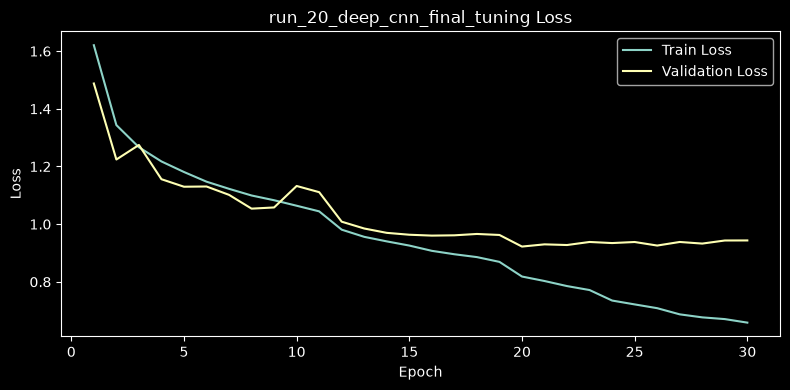

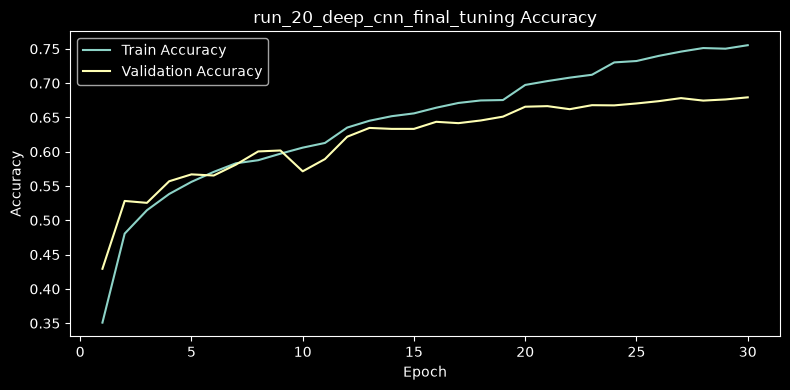

best_val_accuracy,▁▄▄▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇███████████
best_val_epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▆▇▇▇▇▇█
best_val_macro_f1,▁▃▃▄▄▄▄▅▅▅▅▅▇▇▇▇▇▇▇▇▇▇████████
epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
learning_rate,██████████▄▄▄▄▄▄▄▄▃▃▃▃▂▂▂▁▁▁▁▁
train_accuracy,▁▃▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇███████
train_loss,█▆▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁
train_macro_f1,▁▃▃▄▄▄▄▄▄▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇██████
val_accuracy,▁▄▄▅▅▅▅▆▆▅▅▆▇▇▇▇▇▇▇███████████
val_loss,█▅▅▄▄▄▃▃▃▄▃▂▂▂▂▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁
+1,...


,run_name,model,experiment_type,optimizer,scheduler,learning_rate,dropout,weight_decay,augmentation,epochs,epochs_trained,num_parameters,best_val_epoch,best_val_accuracy,best_val_macro_f1
0,run_20_deep_cnn_final_tuning,deep_cnn,final_longer_training_test,Adam,plateau,0.001,0.3,0.0001,light,30,30,1765479,30,0.679298,0.656758


In [14]:
deep_cnn_results = []
deep_cnn_histories = {}

for run_config in SELECTED_RUNS:
    result, history_df = run_deep_cnn_experiment(
        run_config
    )

    deep_cnn_results.append(result)

    deep_cnn_histories[
        run_config["run_name"]
    ] = history_df

deep_cnn_results_df = pd.DataFrame(
    deep_cnn_results
)

deep_cnn_results_df

## Results

In [15]:
if "best_val_accuracy" in deep_cnn_results_df.columns:
    deep_cnn_results_df.sort_values(
        "best_val_accuracy",
        ascending=False,
    )
else:
    deep_cnn_results_df